# Software Delivery Performance (DORA Metrics)

**Section 4 of Baseline System Productivity Report**

> DORA metrics provide the clearest picture of an organization's delivery capability and stability.

## What we're measuring

- **Deployment Frequency**: How often we ship to production
- **Change Lead Time**: Time from first commit to deployed in production

*CFR (Change Fail Rate) and MTTR (Time to Recovery) are out of scope for this baseline.*

## Data source

Swarmia `SWARMIA_DEPLOYMENTS` table with pre-calculated DORA fields.

---

## Caveats

- **Data availability varies by area** - Sports/Platform/Player start Aug 2025, Social goes back to Oct 2023
- **Production only** - Filtered by environment; excludes staging, test, infra/tooling, rollbacks
- **CLT can be skewed** - Non-deployed code (e.g., test-only PRs) sits dormant, then gets deployed with a later change → artificially long CLT. Use median, not average.
- **Team hierarchy evolves** - We filter out area-level names but can't perfectly distinguish tribes from squads

---

In [18]:
import snowflake.connector
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Connect using SSO (will open browser)
conn = snowflake.connector.connect(
    account='wt74883-sb_prod',
    user='jeroen.vaelen@happening.xyz',
    authenticator='externalbrowser'
)

def run_query(sql):
    """Run SQL and return pandas DataFrame"""
    cur = conn.cursor()
    cur.execute(sql)
    df = cur.fetch_pandas_all()
    df.columns = df.columns.str.lower()
    return df

print('Connected!')

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/2c8cda8f-751e-4798-8680-5761f91d4e40/saml2?SAMLRequest=lZJdb9owGIX%2FSuRdJ3ESPoIFVKy0G%2BsXgrRVdzMZ2wEPxw6206T%2Ffk4Aqbtopd5Fzjl%2Bjt%2Fzji%2BaQnivTBuu5AREAQQek0RRLrcT8Jhd%2BynwjMWSYqEkm4A3ZsDFdGxwIUo0q%2BxOrtihYsZ67iJpUPtjAiotkcKGGyRxwQyyBK1nd7coDiDCxjBtHQ6cLNRwx9pZW6IwrOs6qJNA6W0YQwhDOAqdqpV8A%2B8Q5eeMUiuriBJnS%2BPe9AEiCmGvRTiFIyxPxu9cHkfwGWVzFBn0M8uW%2FvJhnQFvdn7dpZKmKpheM%2F3KCXtc3R4DmDaBHfbSNPHN5o9LSgMjVZ0LvGdEFWVl3Z2B%2BwpzRkOhttxNajGfgHLP6VWf3u%2BfV7vD3wd7yFi2vnkisGqKZ7z%2BUd81vxLZbzbNy4bQKwK8p3OvcdvrwpiKLWTbpnVHMB74MPbhIItSBBOUpEECk9%2FAm7s2ucS2c54jdzmCghOtjMqtkoJL1qWMSUooTnN%2F2I%2BY3xuOUj8dpNDvDwdRPopoj%2FVg2HYWg%2BPeoC6Inn5tGuPwvfe0gPeuk8V8qQQnb9610gW2H1cWBVF3wqmfd1LECszFjFLNjHHVCaHqS82wdXtudcVAOD1S%2F9%2F06T8%3D&RelayState=ver%3A3-hint%3A491009301606406-ETMsDgAAAZw0H7G%2FABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEC5UgUwVwrXwYhcTK19gEa4AAACg

 pip install snowflake-connector-python[secure-local-storage]


In [19]:
# =============================================================================
# REUSABLE SQL BUILDING BLOCKS
# =============================================================================

# Areas we have deployment environment filters for
TRACKED_AREAS = ['Player', 'Sports', 'Social', 'Platform']
ALL_AREAS = ['Player', 'Sports', 'Social', 'Platform', 'Core Experience', 'Data', 'Gaming']

# Production environment filter (combined)
ENV_FILTER = """(
    deployment_environment LIKE 'backend.social/production%'
    OR deployment_environment IN ('engprod-prod/tools-bazel','engprod-prod/tools-prod','meta-prod/betler','meta-prod/graph','meta-prod/meta-system','meta-prod/meta-system-remote','ops-prod/sre-argocd')
    OR deployment_environment LIKE 'content-prod/%' 
    OR deployment_environment LIKE 'incubator-prod/%' 
    OR deployment_environment LIKE 'trading-prod/%'
    OR (ARRAY_CONTAINS('Player'::variant, involved_team_names) 
        AND LENGTH(deployment_app_name) = 6 
        AND (deployment_environment = 'production' OR deployment_environment = 'prod'))
)"""

# Per-area filters (for queries that need area-specific breakdown)
# IMPORTANT: Wrap multi-condition filters in parentheses to avoid AND/OR precedence bugs
AREA_FILTERS = {
    'Social': "deployment_environment LIKE 'backend.social/production%'",
    'Player': "(ARRAY_CONTAINS('Player'::variant, involved_team_names) AND LENGTH(deployment_app_name) = 6 AND (deployment_environment = 'production' OR deployment_environment = 'prod'))",
    'Sports': "(deployment_environment LIKE 'content-prod/%' OR deployment_environment LIKE 'incubator-prod/%' OR deployment_environment LIKE 'trading-prod/%')",
    'Platform': "deployment_environment IN ('engprod-prod/tools-bazel','engprod-prod/tools-prod','meta-prod/betler','meta-prod/graph','meta-prod/meta-system','meta-prod/meta-system-remote','ops-prod/sre-argocd')",
}

# --- Reusable CTEs ---

CTE_PARENT_TEAMS = """
parent_teams AS (
    SELECT DISTINCT t.name
    FROM RAW_MISC.SWARMIA_TEAMS t
    INNER JOIN (
        SELECT DISTINCT parent_team_id as id
        FROM RAW_MISC.SWARMIA_TEAMS
        WHERE parent_team_id IS NOT NULL AND deleted_at IS NULL
    ) p ON t.id = p.id
    WHERE t.deleted_at IS NULL
)"""

# Team area lookup: finds the area for each team by traversing the hierarchy
# Special case: flat teams like "Social" that ARE the area (no parent) are included directly
CTE_TEAM_AREA_LOOKUP = f"""
team_ancestors AS (
    SELECT t.id, t.name as team_name, t.parent_team_id, p.name as parent_name, 1 as depth
    FROM RAW_MISC.SWARMIA_TEAMS t
    LEFT JOIN RAW_MISC.SWARMIA_TEAMS p ON t.parent_team_id = p.id
    WHERE t.deleted_at IS NULL
    UNION ALL
    SELECT ta.id, ta.team_name, p.parent_team_id, gp.name as parent_name, ta.depth + 1
    FROM team_ancestors ta
    JOIN RAW_MISC.SWARMIA_TEAMS p ON ta.parent_team_id = p.id
    LEFT JOIN RAW_MISC.SWARMIA_TEAMS gp ON p.parent_team_id = gp.id
    WHERE p.deleted_at IS NULL AND ta.depth < 10
),
team_areas AS (
    SELECT id, team_name, parent_name as area
    FROM team_ancestors
    WHERE parent_name IN {tuple(ALL_AREAS)}
    QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY depth ASC) = 1
),
flat_area_teams AS (
    -- Teams that ARE the area itself (no parent, name matches area)
    SELECT name as team_name, name as area
    FROM RAW_MISC.SWARMIA_TEAMS
    WHERE parent_team_id IS NULL 
        AND name IN {tuple(TRACKED_AREAS)}
        AND deleted_at IS NULL
),
team_area_lookup AS (
    SELECT team_name, area FROM team_areas WHERE area IN {tuple(TRACKED_AREAS)}
    UNION
    SELECT team_name, area FROM flat_area_teams
)"""

CTE_DATE_RANGE_3MO = """
date_range AS (
    SELECT DATEDIFF('day', 
        DATEADD('month', -3, DATE_TRUNC('month', CURRENT_DATE)),
        DATE_TRUNC('month', CURRENT_DATE)
    ) as total_days
)"""

CTE_FILTERED_DEPLOYS_3MO = f"""
filtered_deploys AS (
    SELECT * FROM RAW_MISC.SWARMIA_DEPLOYMENTS
    WHERE deployed_at >= DATEADD('month', -3, DATE_TRUNC('month', CURRENT_DATE))
        AND DATE_TRUNC('month', deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
        AND {ENV_FILTER}
)"""

print("✓ SQL building blocks defined")
print(f"  Tracked areas: {', '.join(TRACKED_AREAS)}")

✓ SQL building blocks defined
  Tracked areas: Player, Sports, Social, Platform


## Deep Dive: Deployment Frequency

How often can teams ship? This is a proxy for delivery capability - elite teams can deploy whenever they need to.

**Important**: Raw deploy counts are misleading. "We deploy 300 times/month" tells you nothing useful. What matters is:
1. Can teams deploy **when they need to**? (cadence)
2. What's the **distribution**? (how many teams have this capability)

Let's start with the trend, then dig into what the numbers really mean.

In [20]:
# Deployment Frequency - Monthly trend by area (Raw and Normalized)
# Charts go back to 2024 to show when data started for each area
queries = []
for area, filter_clause in AREA_FILTERS.items():
    queries.append(f"""
        SELECT 
            '{area}' as area,
            DATE_TRUNC('month', deployed_at)::DATE as month,
            COUNT(*) as deployments,
            COUNT(DISTINCT deployment_app_name) as unique_services,
            COUNT(DISTINCT DATE_TRUNC('day', deployed_at)) as days_with_deploys,
            ROUND(COUNT(*) * 1.0 / NULLIF(COUNT(DISTINCT deployment_app_name), 0), 1) as deploys_per_service
        FROM RAW_MISC.SWARMIA_DEPLOYMENTS 
        WHERE {filter_clause}
            AND deployed_at >= '2024-01-01'
            AND DATE_TRUNC('month', deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
        GROUP BY 1, 2
    """)

df_deploy_freq = run_query(" UNION ALL ".join(queries) + " ORDER BY area, month")

print("Deployment Frequency by Area (Monthly)")
print("=" * 60)
print("Note: Data availability varies by area - Sports/Platform/Player start Aug 2025")
df_deploy_freq.tail(20)

Deployment Frequency by Area (Monthly)
Note: Data availability varies by area - Sports/Platform/Player start Aug 2025


,area,month,deployments,unique_services,days_with_deploys,deploys_per_service
22,Social,2024-12-01,47,42,8,1.1
23,Social,2025-01-01,17,15,10,1.1
24,Social,2025-02-01,30,22,12,1.4
25,Social,2025-03-01,49,34,14,1.4
26,Social,2025-04-01,31,19,14,1.6
27,Social,2025-05-01,52,32,15,1.6
28,Social,2025-06-01,37,21,17,1.8
29,Social,2025-07-01,48,30,18,1.6
30,Social,2025-08-01,21,14,8,1.5
31,Social,2025-09-01,48,26,15,1.8


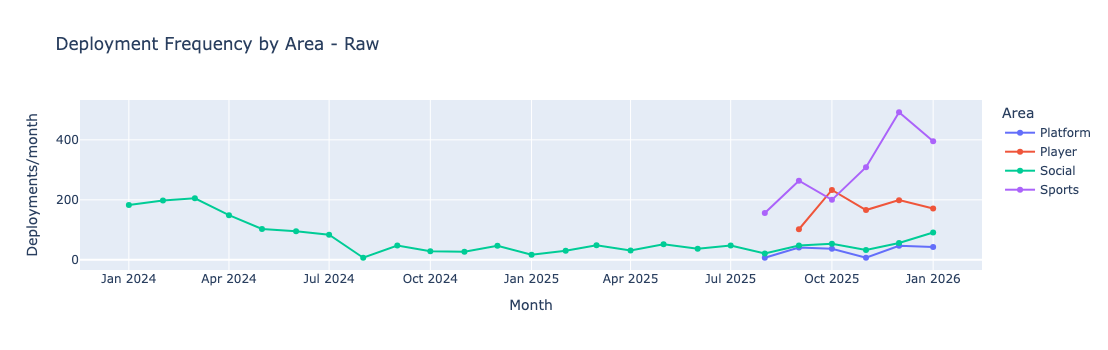

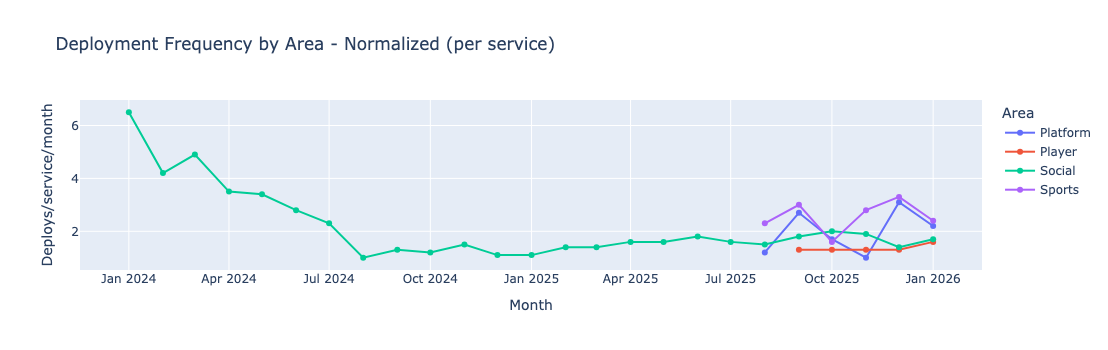


Latest month (Jan 2026):
  700 deployments across 346 services
  - Sports: 395 deploys (167 services)
  - Player: 171 deploys (106 services)
  - Social: 91 deploys (53 services)
  - Platform: 43 deploys (20 services)


In [21]:
# Visualize: Raw deployments
fig1 = px.line(df_deploy_freq, x='month', y='deployments', color='area',
               title='Deployment Frequency by Area - Raw',
               markers=True)
fig1.update_layout(
    yaxis_title='Deployments/month',
    xaxis_title='Month',
    legend_title='Area',
    height=350
)
fig1.show()

# Visualize: Normalized (per service)
fig2 = px.line(df_deploy_freq, x='month', y='deploys_per_service', color='area',
               title='Deployment Frequency by Area - Normalized (per service)',
               markers=True)
fig2.update_layout(
    yaxis_title='Deploys/service/month',
    xaxis_title='Month',
    legend_title='Area',
    height=350
)
fig2.show()

# Key insights from the data
df_deploy_freq['month_dt'] = pd.to_datetime(df_deploy_freq['month'])
latest_month = df_deploy_freq['month_dt'].max()
latest = df_deploy_freq[df_deploy_freq['month_dt'] == latest_month]

total_deploys = latest['deployments'].sum()
total_services = latest['unique_services'].sum()

print(f"\nLatest month ({latest_month.strftime('%b %Y')}):")
print(f"  {int(total_deploys)} deployments across {int(total_services)} services")
for _, row in latest.sort_values('deployments', ascending=False).iterrows():
    print(f"  - {row['area']}: {int(row['deployments'])} deploys ({int(row['unique_services'])} services)")

### Team-Level Cadence

The more useful question: how many teams can deploy frequently? Let's look at the distribution across teams.

In [22]:
# Team-level deployment cadence (last 3 months)
#
# Coverage: ~24 of 71 total squads (only tracked areas + ≥3 deploy days)
# Not included: Data (13), Gaming (7), Core Experience (5), Unknown (7)

df_team_cadence = run_query(f"""
WITH {CTE_DATE_RANGE_3MO}, {CTE_PARENT_TEAMS}, {CTE_FILTERED_DEPLOYS_3MO},
team_deploys AS (
    SELECT f.value::string as team_name, DATE_TRUNC('day', deployed_at)::DATE as deploy_date
    FROM filtered_deploys d, LATERAL FLATTEN(input => d.involved_team_names) f
    WHERE f.value::string NOT IN (SELECT name FROM parent_teams)
),
team_stats AS (
    SELECT team_name,
        COUNT(DISTINCT deploy_date) as deploy_days,
        COUNT(DISTINCT deploy_date) * 100.0 / (SELECT total_days FROM date_range) as cadence_pct
    FROM team_deploys GROUP BY 1
    HAVING COUNT(DISTINCT deploy_date) >= 3
)
SELECT team_name, deploy_days, ROUND(cadence_pct, 1) as cadence_pct,
    CASE 
        WHEN cadence_pct >= 80 THEN 'Elite (daily)'
        WHEN cadence_pct >= 40 THEN 'High (2-3x/week)'
        WHEN cadence_pct >= 20 THEN 'Medium (weekly)'
        ELSE 'Low (<weekly)'
    END as cadence_tier
FROM team_stats ORDER BY cadence_pct DESC
""")

print(f"Team Cadence Distribution (Last 3 Months)")
print(f"=" * 60)
print(f"Teams in analysis: {len(df_team_cadence)} of 71 total squads")

tier_counts = df_team_cadence['cadence_tier'].value_counts()
tier_order = ['Elite (daily)', 'High (2-3x/week)', 'Medium (weekly)', 'Low (<weekly)']
print(f"\nDistribution:")
for tier in tier_order:
    count = tier_counts.get(tier, 0)
    pct = count / len(df_team_cadence) * 100
    print(f"  {tier}: {count} teams ({pct:.0f}%)")

print(f"\nAll teams:")
display(df_team_cadence)

Team Cadence Distribution (Last 3 Months)
Teams in analysis: 24 of 71 total squads

Distribution:
  Elite (daily): 0 teams (0%)
  High (2-3x/week): 3 teams (12%)
  Medium (weekly): 9 teams (38%)
  Low (<weekly): 12 teams (50%)

All teams:


,team_name,deploy_days,cadence_pct,cadence_tier
0,Transact,50,54.3,High (2-3x/week)
1,Release Engineering,45,48.9,High (2-3x/week)
2,App Frameworks,39,42.4,High (2-3x/week)
3,Betting Platform,35,38.0,Medium (weekly)
4,Risk,32,34.8,Medium (weekly)
5,Social,32,34.8,Medium (weekly)
6,Player Account - PAMster,30,32.6,Medium (weekly)
7,Manage Platform - Pasta,30,32.6,Medium (weekly)
8,Feeds Integrations,28,30.4,Medium (weekly)
9,Grayskull,26,28.3,Medium (weekly)


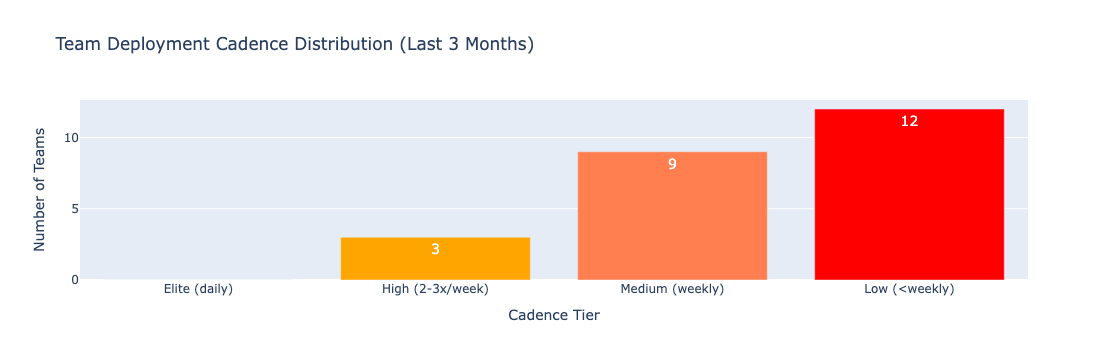


Key insight:
  12% of teams (3/24) deploy at least 2-3x per week
  12 teams deploy less than weekly - potential delivery bottlenecks
  Top performers: Transact, Release Engineering, App Frameworks


In [23]:
# Visualize team cadence distribution
tier_order = ['Elite (daily)', 'High (2-3x/week)', 'Medium (weekly)', 'Low (<weekly)']
tier_colors = {'Elite (daily)': 'green', 'High (2-3x/week)': 'orange', 
               'Medium (weekly)': 'coral', 'Low (<weekly)': 'red'}

# Create summary dataframe
tier_summary = df_team_cadence['cadence_tier'].value_counts().reindex(tier_order).fillna(0).reset_index()
tier_summary.columns = ['tier', 'count']
tier_summary['pct'] = (tier_summary['count'] / tier_summary['count'].sum() * 100).round(1)

fig = px.bar(tier_summary, x='tier', y='count', 
             title='Team Deployment Cadence Distribution (Last 3 Months)',
             text='count',
             color='tier',
             color_discrete_map=tier_colors,
             category_orders={'tier': tier_order})
fig.update_traces(textposition='inside', textfont=dict(color='white', size=14))
fig.update_layout(
    xaxis_title='Cadence Tier',
    yaxis_title='Number of Teams',
    showlegend=False
)
fig.show()

# Key insight - calculated from actual data
elite_high = tier_summary[tier_summary['tier'].isin(['Elite (daily)', 'High (2-3x/week)'])]['count'].sum()
elite_high_pct = elite_high / len(df_team_cadence) * 100
low_count = int(tier_summary[tier_summary['tier'] == 'Low (<weekly)']['count'].sum())

top_teams = df_team_cadence.head(3)['team_name'].tolist()

print(f"\nKey insight:")
print(f"  {elite_high_pct:.0f}% of teams ({int(elite_high)}/{len(df_team_cadence)}) deploy at least 2-3x per week")
print(f"  {low_count} teams deploy less than weekly - potential delivery bottlenecks")
print(f"  Top performers: {', '.join(top_teams)}")

In [27]:
# Team cadence distribution BY AREA (using org hierarchy for area assignment)

df_area_team_cadence = run_query(f"""
WITH RECURSIVE {CTE_TEAM_AREA_LOOKUP}, {CTE_DATE_RANGE_3MO}, {CTE_PARENT_TEAMS}, {CTE_FILTERED_DEPLOYS_3MO},
team_deploys AS (
    SELECT tal.area, f.value::string as team_name, DATE_TRUNC('day', deployed_at)::DATE as deploy_date
    FROM filtered_deploys d, LATERAL FLATTEN(input => d.involved_team_names) f
    INNER JOIN team_area_lookup tal ON f.value::string = tal.team_name
    WHERE f.value::string NOT IN (SELECT name FROM parent_teams)
),
team_stats AS (
    SELECT area, team_name,
        COUNT(DISTINCT deploy_date) as deploy_days,
        COUNT(DISTINCT deploy_date) * 100.0 / (SELECT total_days FROM date_range) as cadence_pct
    FROM team_deploys GROUP BY 1, 2
    HAVING COUNT(DISTINCT deploy_date) >= 3
)
SELECT area, team_name, deploy_days, ROUND(cadence_pct, 1) as cadence_pct,
    CASE 
        WHEN cadence_pct >= 80 THEN 'Elite'
        WHEN cadence_pct >= 40 THEN 'High'
        WHEN cadence_pct >= 20 THEN 'Medium'
        ELSE 'Low'
    END as cadence_tier
FROM team_stats ORDER BY area, cadence_pct DESC
""")

# Aggregate by area
tier_order = ['Elite', 'High', 'Medium', 'Low']
area_tier_counts = df_area_team_cadence.groupby(['area', 'cadence_tier']).size().unstack(fill_value=0)
area_tier_counts = area_tier_counts.reindex(columns=tier_order, fill_value=0)
area_tier_counts['total'] = area_tier_counts.sum(axis=1)
area_tier_counts['pct_high_plus'] = ((area_tier_counts['Elite'] + area_tier_counts['High']) / area_tier_counts['total'] * 100).round(0)
area_tier_counts = area_tier_counts.sort_values('pct_high_plus', ascending=False)

print("Team Cadence Distribution by Area (Last 3 Months)")
print("=" * 60)
print(area_tier_counts[['Elite', 'High', 'Medium', 'Low', 'total', 'pct_high_plus']])

Team Cadence Distribution by Area (Last 3 Months)
cadence_tier  Elite  High  Medium  Low  total  pct_high_plus
area                                                        
Platform          0     2       0    0      2          100.0
Player            0     1       4    6     11            9.0
Social            0     0       1    0      1            0.0
Sports            0     0       4    3      7            0.0


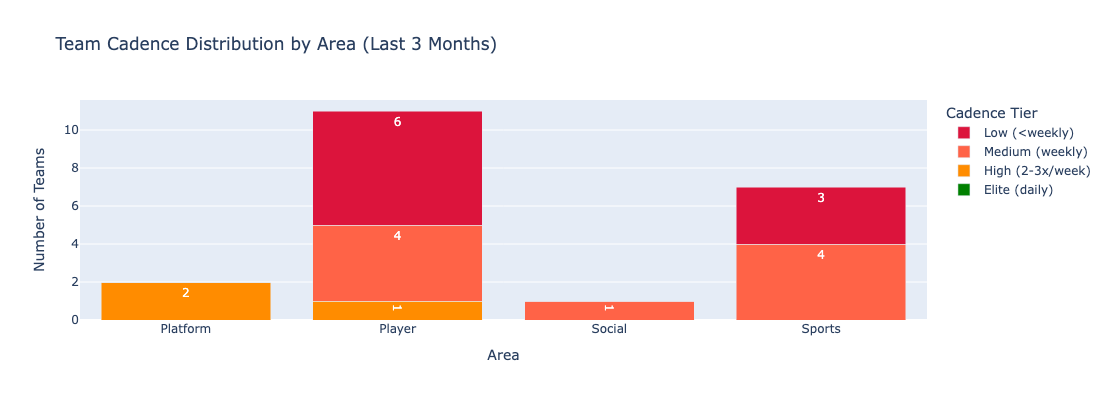


Teams by Area and Cadence Tier:


,Area,Team,Cadence %,Tier
0,Platform,Release Engineering,48.9,High
1,Platform,App Frameworks,42.4,High
2,Player,Transact,54.3,High
3,Player,Player Account - PAMster,32.6,Medium
4,Player,Manage Platform - Pasta,32.6,Medium
5,Player,Grayskull,28.3,Medium
6,Player,Player Onboarding - Backend,26.1,Medium
7,Player,Thundercats,14.1,Low
8,Player,Player Identity - OctoPAM,13.0,Low
9,Player,sbClub Migration,13.0,Low


In [28]:
# Stacked bar: Team cadence distribution by area
tier_colors = {'Elite': 'green', 'High': '#FF8C00', 'Medium': '#FF6347', 'Low': '#DC143C'}
tier_order = ['Elite', 'High', 'Medium', 'Low']
tier_labels = {
    'Elite': 'Elite (daily)',
    'High': 'High (2-3x/week)',
    'Medium': 'Medium (weekly)',
    'Low': 'Low (<weekly)'
}

areas = area_tier_counts.index.tolist()

fig = go.Figure()
for tier in tier_order:
    fig.add_trace(go.Bar(
        name=tier_labels[tier],
        x=areas,
        y=area_tier_counts[tier],
        marker_color=tier_colors[tier],
        text=area_tier_counts[tier].apply(lambda x: str(int(x)) if x > 0 else ''),
        textposition='inside',
        textfont=dict(color='white', size=12)
    ))

fig.update_layout(
    barmode='stack',
    title='Team Cadence Distribution by Area (Last 3 Months)',
    xaxis_title='Area',
    yaxis_title='Number of Teams',
    legend_title='Cadence Tier',
    height=400
)
fig.show()

# Show team table
print("\nTeams by Area and Cadence Tier:")
print("=" * 70)
team_table = df_area_team_cadence[['area', 'team_name', 'cadence_pct', 'cadence_tier']].copy()
team_table = team_table.sort_values(['area', 'cadence_pct'], ascending=[True, False])
team_table.columns = ['Area', 'Team', 'Cadence %', 'Tier']
display(team_table.reset_index(drop=True))

### Going Deeper: Per-Service Cadence

Team-level cadence shows organizational capability. But teams own multiple services - let's see deployment cadence at the service level.

**Why this matters:** A team like Transact can have "High" cadence (~50% of days) while each individual service they own only deploys weekly (~15%). That's because they're deploying *different* services on different days. This is healthy microservices behavior - high team delivery capability, with each small service changing at its own pace.

| Tier | Team threshold | Service threshold |
|------|---------------|-------------------|
| High | ≥40% (2-3x/week) | ≥20% (2x/week) |
| Medium | ≥20% (weekly) | ≥10% (weekly) |
| Low | <20% | ≥5% (bi-weekly) |
| Very Low | - | <5% |

*Note: Cadence = % of days with at least one deployment. Over a 3-month period, bursts average out.*

In [29]:
# Per-service deployment cadence (last 3 months)
# Note: Thresholds are lower than team cadence because a single service
# won't deploy as often as a team (which owns multiple services)

df_service_freq = run_query(f"""
WITH {CTE_DATE_RANGE_3MO}, {CTE_FILTERED_DEPLOYS_3MO},
service_deploys AS (
    SELECT 
        deployment_app_name as service,
        CASE 
            WHEN deployment_environment LIKE 'backend.social/production%' THEN 'Social'
            WHEN deployment_environment IN ('engprod-prod/tools-bazel','engprod-prod/tools-prod','meta-prod/betler','meta-prod/graph','meta-prod/meta-system','meta-prod/meta-system-remote','ops-prod/sre-argocd') THEN 'Platform'
            WHEN (deployment_environment LIKE 'content-prod/%' OR deployment_environment LIKE 'incubator-prod/%' OR deployment_environment LIKE 'trading-prod/%') THEN 'Sports'
            WHEN (ARRAY_CONTAINS('Player'::variant, involved_team_names) 
                  AND LENGTH(deployment_app_name) = 6 
                  AND (deployment_environment = 'production' OR deployment_environment = 'prod')) THEN 'Player'
            ELSE NULL
        END as area,
        DATE_TRUNC('day', deployed_at)::DATE as deploy_date
    FROM filtered_deploys
),
service_stats AS (
    SELECT 
        service,
        area,
        COUNT(DISTINCT deploy_date) as deploy_days,
        COUNT(DISTINCT deploy_date) * 100.0 / (SELECT total_days FROM date_range) as cadence_pct
    FROM service_deploys
    WHERE area IS NOT NULL
    GROUP BY 1, 2
    HAVING COUNT(DISTINCT deploy_date) >= 3
)
SELECT 
    service, 
    area, 
    deploy_days,
    ROUND(cadence_pct, 1) as cadence_pct,
    CASE 
        WHEN cadence_pct >= 20 THEN 'High (2x/week+)'
        WHEN cadence_pct >= 10 THEN 'Medium (weekly)'
        WHEN cadence_pct >= 5 THEN 'Low (bi-weekly)'
        ELSE 'Very Low (<bi-weekly)'
    END as cadence_tier
FROM service_stats 
ORDER BY cadence_pct DESC
""")

print(f"Per-Service Deployment Cadence (Last 3 Months)")
print(f"=" * 60)
print(f"Services with 3+ deploy days: {len(df_service_freq)}")

tier_counts = df_service_freq['cadence_tier'].value_counts()
tier_order = ['High (2x/week+)', 'Medium (weekly)', 'Low (bi-weekly)', 'Very Low (<bi-weekly)']
print(f"\nDistribution:")
for tier in tier_order:
    count = tier_counts.get(tier, 0)
    pct = count / len(df_service_freq) * 100 if len(df_service_freq) > 0 else 0
    print(f"  {tier}: {count} services ({pct:.0f}%)")

print(f"\nTop 10 Most Frequently Deployed Services:")
df_service_freq.head(10)

Per-Service Deployment Cadence (Last 3 Months)
Services with 3+ deploy days: 244

Distribution:
  High (2x/week+): 0 services (0%)
  Medium (weekly): 42 services (17%)
  Low (bi-weekly): 85 services (35%)
  Very Low (<bi-weekly): 117 services (48%)

Top 10 Most Frequently Deployed Services:


,service,area,deploy_days,cadence_pct,cadence_tier
0,sports.tickets.new-presentation-api-public,Sports,14,15.2,Medium (weekly)
1,sports.tickets.decomposer-engine-public,Sports,14,15.2,Medium (weekly)
2,sports.betting.expected-settlement-entity-public,Sports,13,14.1,Medium (weekly)
3,nuvpay,Player,12,13.0,Medium (weekly)
4,sports.content-platform.offer-handler-public,Sports,11,12.0,Medium (weekly)
5,sports.content-platform.category-entity-public,Sports,11,12.0,Medium (weekly)
6,sports.content-platform.origin-offer-competiti...,Sports,11,12.0,Medium (weekly)
7,sports.content-platform.referee-entity-public,Sports,11,12.0,Medium (weekly)
8,sports.content-platform.team-sport-player-enti...,Sports,11,12.0,Medium (weekly)
9,sports.content-platform.origin-udf-category-en...,Sports,11,12.0,Medium (weekly)


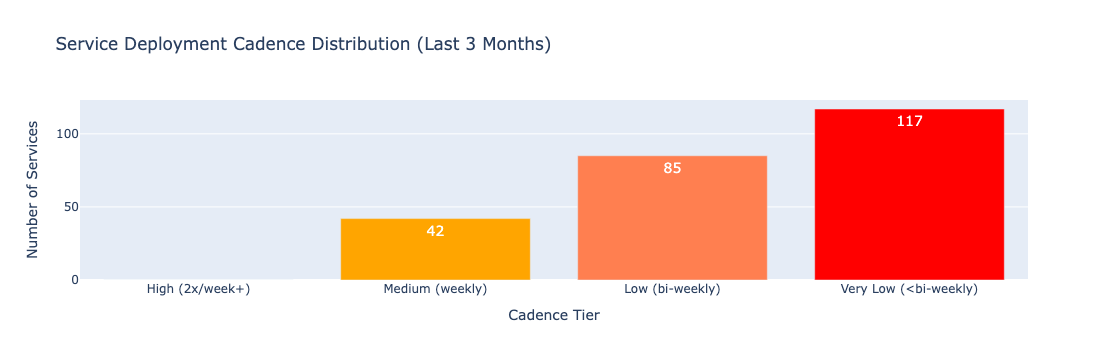


Key insight:
  17% of services deploy at least weekly
  Even our most active service (sports.tickets.new-presentation-api-public) only deploys 15% of days (~weekly)
  No service is on true continuous/daily deployment


In [30]:
# Visualize service cadence distribution
tier_order = ['High (2x/week+)', 'Medium (weekly)', 'Low (bi-weekly)', 'Very Low (<bi-weekly)']
tier_colors = {'High (2x/week+)': 'green', 'Medium (weekly)': 'orange', 
               'Low (bi-weekly)': 'coral', 'Very Low (<bi-weekly)': 'red'}

tier_summary = df_service_freq['cadence_tier'].value_counts().reindex(tier_order).fillna(0).reset_index()
tier_summary.columns = ['tier', 'count']

fig = px.bar(tier_summary, x='tier', y='count',
             title='Service Deployment Cadence Distribution (Last 3 Months)',
             text='count',
             color='tier',
             color_discrete_map=tier_colors,
             category_orders={'tier': tier_order})
fig.update_traces(textposition='inside', textfont=dict(color='white', size=14))
fig.update_layout(
    xaxis_title='Cadence Tier',
    yaxis_title='Number of Services',
    showlegend=False
)
fig.show()

# Key insights
high_medium = tier_summary[tier_summary['tier'].isin(['High (2x/week+)', 'Medium (weekly)'])]['count'].sum()
high_medium_pct = high_medium / len(df_service_freq) * 100 if len(df_service_freq) > 0 else 0

top_service = df_service_freq.iloc[0] if len(df_service_freq) > 0 else None

print(f"\nKey insight:")
print(f"  {high_medium_pct:.0f}% of services deploy at least weekly")
if top_service is not None:
    print(f"  Even our most active service ({top_service['service']}) only deploys {top_service['cadence_pct']:.0f}% of days (~weekly)")
    print(f"  No service is on true continuous/daily deployment")

## Deep Dive: Time to Deploy

### What we're measuring

**Time to Deploy (TTD)**: Time from **PR merged** to **deployed in production**.

This measures deployment pipeline speed - how long does it take to get merged code into production? This complements cycle time (which covers first commit → merge) by showing the "last mile" of delivery.

*Note: Swarmia also provides "Change Lead Time" (first commit → deployed), but we already cover that early phase in cycle time analysis.*

### Benchmarks

There are two common DORA benchmark sets in the industry. We use the stricter one:

| Tier | Stricter Benchmark | Standard Benchmark |
|------|--------------------|--------------------|
| **Elite** | < 1 hour | < 1 day |
| **Fast** | < 1 day | < 1 week |
| **Moderate** | < 1 week | < 1 month |
| **Slow** | > 1 week | > 1 month |

In [89]:
# Time to Deploy - Org-wide Baseline (6 months)
# Single query for true baseline stats (not mean of monthly values)
df_ttd_baseline = run_query(f"""
SELECT 
    COUNT(*) as deployments,
    ROUND(AVG(time_to_deploy_seconds) / 3600.0, 1) as avg_ttd_hours,
    ROUND(MEDIAN(time_to_deploy_seconds) / 3600.0, 1) as median_ttd_hours,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY time_to_deploy_seconds) / 3600.0, 1) as p75_ttd_hours,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY time_to_deploy_seconds) / 3600.0, 1) as p90_ttd_hours
FROM RAW_MISC.SWARMIA_DEPLOYMENTS 
WHERE {ENV_FILTER}
    AND time_to_deploy_seconds IS NOT NULL
    AND deployed_at >= DATEADD('month', -6, DATE_TRUNC('month', CURRENT_DATE))
    AND DATE_TRUNC('month', deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
""")

# Convert to float
for col in df_ttd_baseline.columns:
    df_ttd_baseline[col] = df_ttd_baseline[col].astype(float)

# Helper to format hours with days
def format_hours(h):
    if h < 24:
        return f"{h:.1f}h"
    else:
        return f"{h:.1f}h ({h/24:.1f} days)"

# Extract values
deployments = int(df_ttd_baseline['deployments'].iloc[0])
avg_ttd = df_ttd_baseline['avg_ttd_hours'].iloc[0]
median_ttd = df_ttd_baseline['median_ttd_hours'].iloc[0]
p75_ttd = df_ttd_baseline['p75_ttd_hours'].iloc[0]
p90_ttd = df_ttd_baseline['p90_ttd_hours'].iloc[0]
ratio = avg_ttd / median_ttd if median_ttd > 0 else 0

# Determine tier and gap
if median_ttd < 1:
    tier = "Elite"
    gap = None
elif median_ttd < 24:
    tier = "Fast"
    gap = f"{format_hours(median_ttd - 1)} to Elite"
elif median_ttd < 168:
    tier = "Moderate"
    gap = f"{format_hours(median_ttd - 24)} to Fast"
else:
    tier = "Slow"
    gap = f"{format_hours(median_ttd - 168)} to Moderate"

print("=" * 60)
print("TIME TO DEPLOY BASELINE (Org-wide, Last 6 Months)")
print("=" * 60)
print(f"\n  Deployments analyzed: {deployments:,}")
print(f"\n  Median TTD:   {format_hours(median_ttd):<20} ← typical deployment")
print(f"  Average TTD:  {format_hours(avg_ttd):<20} ← pulled up by outliers ({ratio:.1f}x median)")
print(f"  P75 TTD:      {format_hours(p75_ttd)}")
print(f"  P90 TTD:      {format_hours(p90_ttd)}")
print(f"\n  Performance Tier: {tier}")
if gap:
    print(f"  Gap to next tier: {gap}")

Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/2c8cda8f-751e-4798-8680-5761f91d4e40/saml2?SAMLRequest=lZJdb9owGIX%2FSuRdJ7HTkA8LqBioGhUMVMI07WYytgNWEzu1nYbu188JIHUXrbS7yDnHz%2FF73vH9ua68V66NUHICUACBxyVVTMjjBOyLBz8DnrFEMlIpySfgjRtwPx0bUlcNnrX2JJ%2F4S8uN9dxF0uD%2BxwS0WmJFjDBYkpobbCnezdYrHAUQE2O4tg4HrhZmhGOdrG1wGHZdF3R3gdLHMIIQhjAPnaqXfAHvEM3njEYrq6iqbpaze9MHCBTCuEc4hSNsr8avQl5G8BnlcBEZ%2FK0otv52syuAN7u9bq6kaWuud1y%2FCsr3T6tLANMnsGmcZXe%2BOfx2SVlgpOrKijxzquqmte7OwH2FJWdhpY7CTWq5mIDmWbDDY3ceHeplzqLj5s8pSfc%2FV2in%2BIjMT8fzpqDr5NGgl1lRrynwftx6jfpel8a0fCn7Nq07glHiw8iHaYFyHCM8yoMEoV%2FAW7g2hSR2cN4iDzmCWlCtjCqtkpWQfEgZ0YwykpV%2BOkLcj9M887Mkg%2F4oTVCZIxbzGIZ9ZxG47A0egujp%2F01jHL73Xhfwu%2BtkudiqStA370HpmtiPK0MBGk4E88tBinlNRDVjTHNjXHVVpbq55sS6Pbe65SCcXqj%2Fbvr0Lw%3D%3D&RelayState=ver%3A3-hint%3A491009301606406-ETMsDgAAAZw5oBm7ABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEERIXl31A08ExCDLFXmyffEAAACg3GqaDimvZ8oNBD

 pip install snowflake-connector-python[secure-local-storage]


TIME TO DEPLOY BASELINE (Org-wide, Last 6 Months)

  Deployments analyzed: 3,065

  Median TTD:   70.4h (2.9 days)     ← typical deployment
  Average TTD:  253.4h (10.6 days)   ← pulled up by outliers (3.6x median)
  P75 TTD:      252.5h (10.5 days)
  P90 TTD:      578.8h (24.1 days)

  Performance Tier: Moderate
  Gap to next tier: 46.4h (1.9 days) to Fast


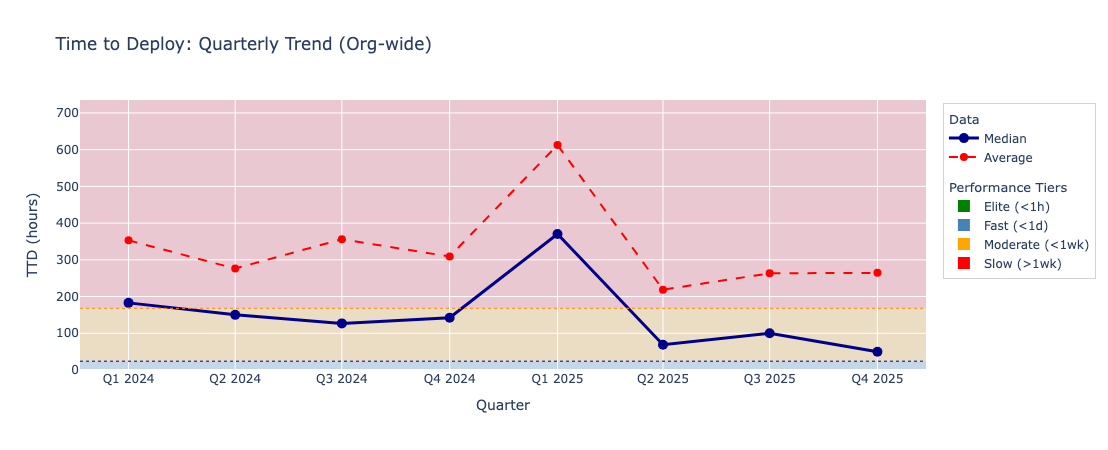


Key insight:
  The average (264h) is 5.3x higher than the median (50h).
  This gap indicates a skewed distribution - outliers are pulling up the average.
  The median is more representative of a typical deployment.


In [90]:
# TTD Quarterly Trend - Org-wide (avg vs median to show skew)
df_ttd_quarterly = run_query(f"""
SELECT 
    DATE_TRUNC('quarter', deployed_at)::DATE as quarter,
    COUNT(*) as deployments,
    ROUND(MEDIAN(time_to_deploy_seconds) / 3600.0, 1) as median_ttd_hours,
    ROUND(AVG(time_to_deploy_seconds) / 3600.0, 1) as avg_ttd_hours
FROM RAW_MISC.SWARMIA_DEPLOYMENTS 
WHERE {ENV_FILTER}
    AND time_to_deploy_seconds IS NOT NULL
    AND deployed_at >= '2024-01-01'
    AND DATE_TRUNC('quarter', deployed_at) < DATE_TRUNC('quarter', CURRENT_DATE)
GROUP BY 1
HAVING COUNT(*) >= 30  -- Only quarters with meaningful data
ORDER BY 1
""")

# Convert types
df_ttd_quarterly['median_ttd_hours'] = df_ttd_quarterly['median_ttd_hours'].astype(float)
df_ttd_quarterly['avg_ttd_hours'] = df_ttd_quarterly['avg_ttd_hours'].astype(float)
df_ttd_quarterly['deployments'] = df_ttd_quarterly['deployments'].astype(int)
df_ttd_quarterly['quarter'] = pd.to_datetime(df_ttd_quarterly['quarter'])

# Calculate max for y-axis
max_y = max(df_ttd_quarterly['avg_ttd_hours'].max() * 1.2, 200)

# Create line chart with benchmark zones
fig = go.Figure()

# Add shaded benchmark regions
fig.add_shape(type="rect", x0=0, x1=1, y0=0, y1=1, xref="paper", yref="y",
              fillcolor="green", opacity=0.2, layer="below", line_width=0)
fig.add_shape(type="rect", x0=0, x1=1, y0=1, y1=24, xref="paper", yref="y",
              fillcolor="steelblue", opacity=0.2, layer="below", line_width=0)
fig.add_shape(type="rect", x0=0, x1=1, y0=24, y1=168, xref="paper", yref="y",
              fillcolor="orange", opacity=0.2, layer="below", line_width=0)
if max_y > 168:
    fig.add_shape(type="rect", x0=0, x1=1, y0=168, y1=max_y, xref="paper", yref="y",
                  fillcolor="red", opacity=0.15, layer="below", line_width=0)

# Add benchmark lines
fig.add_hline(y=24, line_dash="dot", line_color="darkblue", line_width=1)
fig.add_hline(y=168, line_dash="dot", line_color="darkorange", line_width=1)

# Add median line (primary)
fig.add_trace(go.Scatter(
    x=df_ttd_quarterly['quarter'],
    y=df_ttd_quarterly['median_ttd_hours'],
    mode='lines+markers',
    line=dict(color='darkblue', width=3),
    marker=dict(size=10),
    name='Median',
    legendgroup='data', legendgrouptitle_text='Data'
))

# Add average line
fig.add_trace(go.Scatter(
    x=df_ttd_quarterly['quarter'],
    y=df_ttd_quarterly['avg_ttd_hours'],
    mode='lines+markers',
    line=dict(color='red', width=2, dash='dash'),
    marker=dict(size=8),
    name='Average',
    legendgroup='data'
))

# Add invisible traces for tier legend
for tier, color, label in [
    ('Elite', 'green', 'Elite (<1h)'),
    ('Fast', 'steelblue', 'Fast (<1d)'),
    ('Moderate', 'orange', 'Moderate (<1wk)'),
    ('Slow', 'red', 'Slow (>1wk)')
]:
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=12, color=color, symbol='square'),
        name=label, legendgroup='tiers', legendgrouptitle_text='Performance Tiers'
    ))

fig.update_layout(
    title='Time to Deploy: Quarterly Trend (Org-wide)',
    xaxis_title='Quarter',
    yaxis_title='TTD (hours)',
    yaxis_range=[0, max_y],
    xaxis=dict(tickformat='Q%q %Y', dtick='M3'),
    height=450,
    legend=dict(
        yanchor="top", y=0.99, xanchor="left", x=1.02,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="lightgray", borderwidth=1
    ),
    margin=dict(r=180)
)
fig.show()

# Key insights
if len(df_ttd_quarterly) >= 1:
    latest = df_ttd_quarterly.iloc[-1]
    ratio = latest['avg_ttd_hours'] / latest['median_ttd_hours'] if latest['median_ttd_hours'] > 0 else 0
    print(f"\nKey insight:")
    print(f"  The average ({latest['avg_ttd_hours']:.0f}h) is {ratio:.1f}x higher than the median ({latest['median_ttd_hours']:.0f}h).")
    print(f"  This gap indicates a skewed distribution - outliers are pulling up the average.")
    print(f"  The median is more representative of a typical deployment.")

### TTD Distribution

The baseline tells us the median (~3 days) and average (~11 days) - but where do deployments actually fall across the performance tiers?

In [94]:
# TTD Distribution - Org-wide
# Tiers: Elite (<1h), Fast (<1d), Moderate (<1w), Slow (>1w)
df_ttd_dist = run_query(f"""
SELECT 
    CASE 
        WHEN time_to_deploy_seconds < 3600 THEN '1. < 1 hour'
        WHEN time_to_deploy_seconds < 86400 THEN '2. 1h - 1 day'
        WHEN time_to_deploy_seconds < 604800 THEN '3. 1 day - 1 week'
        ELSE '4. > 1 week'
    END as ttd_bucket,
    CASE 
        WHEN time_to_deploy_seconds < 3600 THEN 'Elite'
        WHEN time_to_deploy_seconds < 86400 THEN 'Fast'
        WHEN time_to_deploy_seconds < 604800 THEN 'Moderate'
        ELSE 'Slow'
    END as tier,
    COUNT(*) as deployments
FROM RAW_MISC.SWARMIA_DEPLOYMENTS 
WHERE {ENV_FILTER}
    AND time_to_deploy_seconds IS NOT NULL
    AND deployed_at >= DATEADD('month', -6, DATE_TRUNC('month', CURRENT_DATE))
    AND DATE_TRUNC('month', deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
GROUP BY 1, 2
ORDER BY 1
""")

# Calculate percentages
df_ttd_dist['deployments'] = df_ttd_dist['deployments'].astype(float)
total = df_ttd_dist['deployments'].sum()
df_ttd_dist['pct'] = (df_ttd_dist['deployments'] / total * 100).round(1)
df_ttd_dist['cumulative_pct'] = df_ttd_dist['pct'].cumsum()

print("TTD Distribution (Org-wide, Last 6 Months)")
print("=" * 60)
df_ttd_dist

TTD Distribution (Org-wide, Last 6 Months)


,ttd_bucket,tier,deployments,pct,cumulative_pct
0,1. < 1 hour,Elite,385.0,12.6,12.6
1,2. 1h - 1 day,Fast,752.0,24.5,37.1
2,3. 1 day - 1 week,Moderate,865.0,28.2,65.3
3,4. > 1 week,Slow,1063.0,34.7,100.0


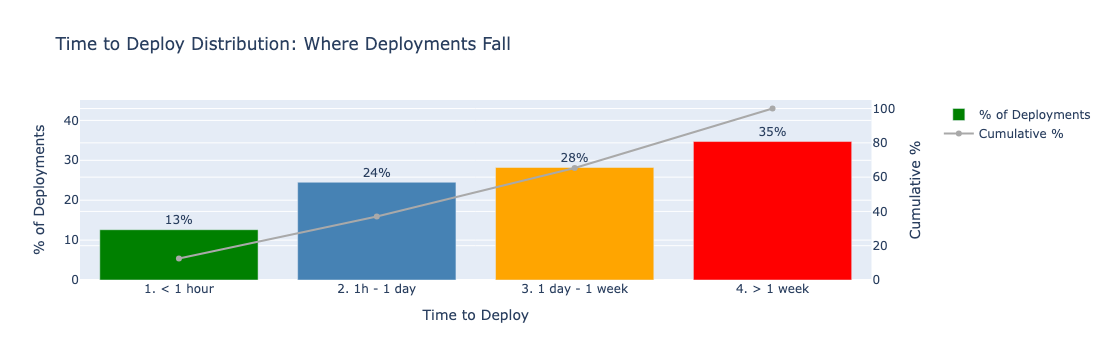


Performance breakdown:
  Elite (<1h):      13%
  Fast (<1 day):    24%
  Moderate (<1 wk): 28%
  Slow (>1 week):   35%

  37% of deployments ship within a day of merge


In [95]:
# Visualize org-wide TTD distribution - bar chart with cumulative line
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Color bars by tier
tier_colors = {'Elite': 'green', 'Fast': 'steelblue', 'Moderate': 'orange', 'Slow': 'red'}
colors = [tier_colors[t] for t in df_ttd_dist['tier']]

fig.add_trace(
    go.Bar(x=df_ttd_dist['ttd_bucket'], y=df_ttd_dist['pct'],
           name='% of Deployments', 
           text=[f'{x:.0f}%' for x in df_ttd_dist['pct']],
           textposition='outside',
           marker_color=colors),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=df_ttd_dist['ttd_bucket'], y=df_ttd_dist['cumulative_pct'],
               name='Cumulative %', mode='lines+markers', line=dict(color='darkgray')),
    secondary_y=True
)

fig.update_layout(
    title='Time to Deploy Distribution: Where Deployments Fall',
    xaxis_title='Time to Deploy'
)
fig.update_yaxes(title_text='% of Deployments', secondary_y=False, range=[0, df_ttd_dist['pct'].max() * 1.3])
fig.update_yaxes(title_text='Cumulative %', secondary_y=True, range=[0, 105])
fig.show()

# Key insights
elite_pct = df_ttd_dist[df_ttd_dist['tier'] == 'Elite']['pct'].sum()
fast_pct = df_ttd_dist[df_ttd_dist['tier'] == 'Fast']['pct'].sum()
moderate_pct = df_ttd_dist[df_ttd_dist['tier'] == 'Moderate']['pct'].sum()
slow_pct = df_ttd_dist[df_ttd_dist['tier'] == 'Slow']['pct'].sum()

print(f"\nPerformance breakdown:")
print(f"  Elite (<1h):      {elite_pct:.0f}%")
print(f"  Fast (<1 day):    {fast_pct:.0f}%")
print(f"  Moderate (<1 wk): {moderate_pct:.0f}%")
print(f"  Slow (>1 week):   {slow_pct:.0f}%")
print(f"\n  {elite_pct + fast_pct:.0f}% of deployments ship within a day of merge")

### TTD by Area

How does deployment speed vary across areas?

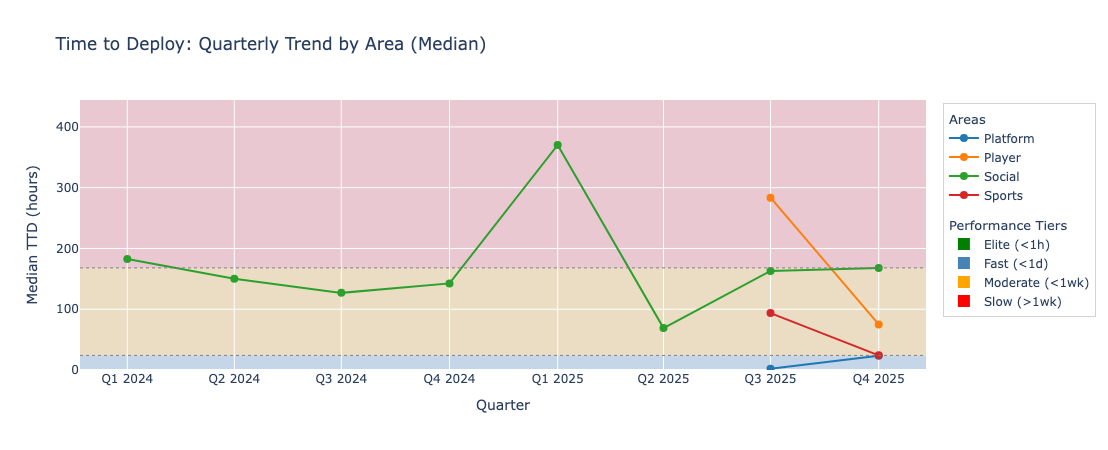


Latest quarter (2025 Qq) by area:
  Platform     23.6h  (Fast)
  Sports       24.1h  (Moderate)
  Player       75.0h  (Moderate)
  Social      167.7h  (Moderate)


In [101]:
# TTD Quarterly Trend by Area
queries = []
for area, filter_clause in AREA_FILTERS.items():
    queries.append(f"""
        SELECT 
            '{area}' as area,
            DATE_TRUNC('quarter', deployed_at)::DATE as quarter,
            COUNT(*) as deployments,
            ROUND(MEDIAN(time_to_deploy_seconds) / 3600.0, 1) as median_ttd_hours
        FROM RAW_MISC.SWARMIA_DEPLOYMENTS 
        WHERE {filter_clause}
            AND time_to_deploy_seconds IS NOT NULL
            AND deployed_at >= '2024-01-01'
            AND DATE_TRUNC('quarter', deployed_at) < DATE_TRUNC('quarter', CURRENT_DATE)
        GROUP BY 1, 2
        HAVING COUNT(*) >= 10  -- Only quarters with meaningful data per area
    """)

df_ttd_quarterly_area = run_query(" UNION ALL ".join(queries) + " ORDER BY area, quarter")
df_ttd_quarterly_area['median_ttd_hours'] = df_ttd_quarterly_area['median_ttd_hours'].astype(float)
df_ttd_quarterly_area['quarter'] = pd.to_datetime(df_ttd_quarterly_area['quarter'])

# Calculate max for y-axis
max_y = max(df_ttd_quarterly_area['median_ttd_hours'].max() * 1.2, 200)

# Create line chart
fig = go.Figure()

# Add shaded benchmark regions
fig.add_shape(type="rect", x0=0, x1=1, y0=0, y1=1, xref="paper", yref="y",
              fillcolor="green", opacity=0.2, layer="below", line_width=0)
fig.add_shape(type="rect", x0=0, x1=1, y0=1, y1=24, xref="paper", yref="y",
              fillcolor="steelblue", opacity=0.2, layer="below", line_width=0)
fig.add_shape(type="rect", x0=0, x1=1, y0=24, y1=168, xref="paper", yref="y",
              fillcolor="orange", opacity=0.2, layer="below", line_width=0)
if max_y > 168:
    fig.add_shape(type="rect", x0=0, x1=1, y0=168, y1=max_y, xref="paper", yref="y",
                  fillcolor="red", opacity=0.15, layer="below", line_width=0)

# Add benchmark lines
fig.add_hline(y=24, line_dash="dot", line_color="gray", line_width=1)
fig.add_hline(y=168, line_dash="dot", line_color="gray", line_width=1)

# Color palette for areas
area_colors = {'Platform': '#1f77b4', 'Player': '#ff7f0e', 'Social': '#2ca02c', 'Sports': '#d62728'}

# Add line per area
for area in df_ttd_quarterly_area['area'].unique():
    area_data = df_ttd_quarterly_area[df_ttd_quarterly_area['area'] == area]
    fig.add_trace(go.Scatter(
        x=area_data['quarter'],
        y=area_data['median_ttd_hours'],
        mode='lines+markers',
        line=dict(width=2, color=area_colors.get(area, 'gray')),
        marker=dict(size=8),
        name=area,
        legendgroup='areas', legendgrouptitle_text='Areas'
    ))

# Add invisible traces for tier legend
for tier, color, label in [
    ('Elite', 'green', 'Elite (<1h)'),
    ('Fast', 'steelblue', 'Fast (<1d)'),
    ('Moderate', 'orange', 'Moderate (<1wk)'),
    ('Slow', 'red', 'Slow (>1wk)')
]:
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=12, color=color, symbol='square'),
        name=label, legendgroup='tiers', legendgrouptitle_text='Performance Tiers'
    ))

fig.update_layout(
    title='Time to Deploy: Quarterly Trend by Area (Median)',
    xaxis_title='Quarter',
    yaxis_title='Median TTD (hours)',
    yaxis_range=[0, max_y],
    xaxis=dict(tickformat='Q%q %Y', dtick='M3'),
    height=450,
    legend=dict(
        yanchor="top", y=0.99, xanchor="left", x=1.02,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="lightgray", borderwidth=1
    ),
    margin=dict(r=180)
)
fig.show()

# Show latest quarter summary by area
latest_q = df_ttd_quarterly_area['quarter'].max()
latest_data = df_ttd_quarterly_area[df_ttd_quarterly_area['quarter'] == latest_q].sort_values('median_ttd_hours')
print(f"\nLatest quarter ({latest_q.strftime('%Y Q%q')}) by area:")
for _, row in latest_data.iterrows():
    tier = 'Elite' if row['median_ttd_hours'] < 1 else 'Fast' if row['median_ttd_hours'] < 24 else 'Moderate' if row['median_ttd_hours'] < 168 else 'Slow'
    print(f"  {row['area']:<10} {row['median_ttd_hours']:>6.1f}h  ({tier})")

In [120]:
# TTD Trend Analysis: Recent 3 months vs Previous 3 months
queries = []
for area, filter_clause in AREA_FILTERS.items():
    queries.append(f"""
        SELECT 
            '{area}' as area,
            CASE 
                WHEN deployed_at >= DATEADD('month', -3, DATE_TRUNC('month', CURRENT_DATE)) THEN 'Recent (3mo)'
                ELSE 'Previous (3mo)'
            END as period,
            COUNT(*) as deployments,
            MEDIAN(time_to_deploy_seconds) / 3600.0 as median_ttd_hours,
            AVG(time_to_deploy_seconds) / 3600.0 as avg_ttd_hours
        FROM RAW_MISC.SWARMIA_DEPLOYMENTS 
        WHERE {filter_clause}
            AND time_to_deploy_seconds IS NOT NULL
            AND deployed_at >= DATEADD('month', -6, DATE_TRUNC('month', CURRENT_DATE))
            AND DATE_TRUNC('month', deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
        GROUP BY 1, 2
    """)

df_trend = run_query(" UNION ALL ".join(queries))
df_trend['median_ttd_hours'] = df_trend['median_ttd_hours'].astype(float)
df_trend['avg_ttd_hours'] = df_trend['avg_ttd_hours'].astype(float)

# Pivot to compare periods
trend_pivot = df_trend.pivot(index='area', columns='period', values='median_ttd_hours').reset_index()
if 'Previous (3mo)' in trend_pivot.columns and 'Recent (3mo)' in trend_pivot.columns:
    trend_pivot['change_hours'] = trend_pivot['Recent (3mo)'] - trend_pivot['Previous (3mo)']
    trend_pivot['change_pct'] = ((trend_pivot['Recent (3mo)'] / trend_pivot['Previous (3mo)'] - 1) * 100).round(1)
    
    print("TTD Trend: Recent 3 Months vs Previous 3 Months (Median)")
    print("=" * 60)
    
    improved = []
    worsened = []
    
    for _, row in trend_pivot.iterrows():
        direction = "↓" if row['change_pct'] < 0 else "↑" if row['change_pct'] > 0 else "→"
        status = "faster" if row['change_pct'] < 0 else "slower" if row['change_pct'] > 0 else "stable"
        print(f"  {row['area']}: {row['Previous (3mo)']:.1f}h → {row['Recent (3mo)']:.1f}h ({direction} {abs(row['change_pct']):.0f}% {status})")
        
        if row['change_pct'] < -10:
            improved.append(row['area'])
        elif row['change_pct'] > 10:
            worsened.append(row['area'])
    
    print(f"\nKey insight:")
    if improved:
        print(f"  Getting faster: {', '.join(improved)}")
    if worsened:
        print(f"  Getting slower: {', '.join(worsened)}")
    if not improved and not worsened:
        print(f"  All areas relatively stable (within ±10%)")
else:
    print("Not enough data for trend comparison")
    print(df_trend)

TTD Trend: Recent 3 Months vs Previous 3 Months (Median)
  Platform: 1.7h → 16.5h (↑ 847% slower)
  Player: 164.1h → 74.9h (↓ 54% faster)
  Social: 129.1h → 186.6h (↑ 44% slower)
  Sports: 100.0h → 23.5h (↓ 76% faster)

Key insight:
  Getting faster: Player, Sports
  Getting slower: Platform, Social


In [102]:
# TTD by Area - avg vs median comparison
queries = []
for area, filter_clause in AREA_FILTERS.items():
    queries.append(f"""
        SELECT 
            '{area}' as area,
            COUNT(*) as deployments,
            ROUND(AVG(time_to_deploy_seconds) / 3600.0, 1) as avg_ttd_hours,
            ROUND(MEDIAN(time_to_deploy_seconds) / 3600.0, 1) as median_ttd_hours
        FROM RAW_MISC.SWARMIA_DEPLOYMENTS 
        WHERE {filter_clause}
            AND time_to_deploy_seconds IS NOT NULL
            AND deployed_at >= DATEADD('month', -6, DATE_TRUNC('month', CURRENT_DATE))
            AND DATE_TRUNC('month', deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
    """)

df_ttd_by_area = run_query(" UNION ALL ".join(queries) + " ORDER BY median_ttd_hours")

# Convert to float
for col in ['deployments', 'avg_ttd_hours', 'median_ttd_hours']:
    df_ttd_by_area[col] = df_ttd_by_area[col].astype(float)

# Add tier based on median
def get_tier(hours):
    if hours < 1: return 'Elite'
    elif hours < 24: return 'Fast'
    elif hours < 168: return 'Moderate'
    else: return 'Slow'

df_ttd_by_area['tier'] = df_ttd_by_area['median_ttd_hours'].apply(get_tier)

print("TTD by Area: Avg vs Median (Last 6 Months)")
print("=" * 60)
df_ttd_by_area

TTD by Area: Avg vs Median (Last 6 Months)


,area,deployments,avg_ttd_hours,median_ttd_hours,tier
0,Platform,182.0,130.3,12.6,Fast
1,Sports,1816.0,153.4,53.3,Moderate
2,Player,871.0,437.1,85.8,Moderate
3,Social,196.0,477.2,168.2,Slow


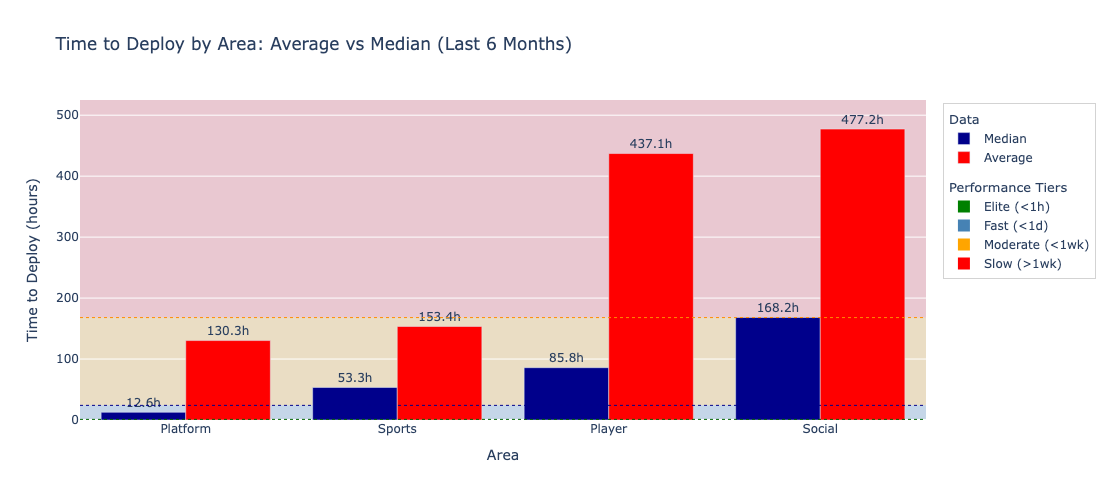


TTD by Area (Last 6 Months):
Area         Median               Tier         Gap to next tier
--------------------------------------------------------------------------------
Platform     12.6h                Fast         11.6h to Elite
Sports       53.3h (2.2d)         Moderate     29.3h (1.2d) to Fast
Player       85.8h (3.6d)         Moderate     61.8h (2.6d) to Fast
Social       168.2h (7.0d)        Slow         0.2h to Moderate


In [103]:
# Visualize TTD by Area: grouped bar chart with benchmark zones
fig = go.Figure()

# Calculate max for y-axis range
max_y = max(df_ttd_by_area['avg_ttd_hours'].max(), 168) * 1.1

# Add shaded regions for each tier
fig.add_shape(type="rect", x0=0, x1=1, y0=0, y1=1, xref="paper", yref="y",
              fillcolor="green", opacity=0.2, layer="below", line_width=0)
fig.add_shape(type="rect", x0=0, x1=1, y0=1, y1=24, xref="paper", yref="y",
              fillcolor="steelblue", opacity=0.2, layer="below", line_width=0)
fig.add_shape(type="rect", x0=0, x1=1, y0=24, y1=168, xref="paper", yref="y",
              fillcolor="orange", opacity=0.2, layer="below", line_width=0)
if max_y > 168:
    fig.add_shape(type="rect", x0=0, x1=1, y0=168, y1=max_y, xref="paper", yref="y",
                  fillcolor="red", opacity=0.15, layer="below", line_width=0)

# Add benchmark lines (no annotations)
fig.add_hline(y=1, line_dash="dot", line_color="darkgreen", line_width=1)
fig.add_hline(y=24, line_dash="dot", line_color="darkblue", line_width=1)
fig.add_hline(y=168, line_dash="dot", line_color="darkorange", line_width=1)

# Add bars
fig.add_trace(go.Bar(
    name='Median',
    x=df_ttd_by_area['area'],
    y=df_ttd_by_area['median_ttd_hours'],
    marker_color='darkblue',
    text=[f'{x:.1f}h' for x in df_ttd_by_area['median_ttd_hours']],
    textposition='outside',
    legendgroup='data', legendgrouptitle_text='Data'
))
fig.add_trace(go.Bar(
    name='Average',
    x=df_ttd_by_area['area'],
    y=df_ttd_by_area['avg_ttd_hours'],
    marker_color='red',
    text=[f'{x:.1f}h' for x in df_ttd_by_area['avg_ttd_hours']],
    textposition='outside',
    legendgroup='data'
))

# Add invisible traces for tier legend
for tier, color, label in [
    ('Elite', 'green', 'Elite (<1h)'),
    ('Fast', 'steelblue', 'Fast (<1d)'),
    ('Moderate', 'orange', 'Moderate (<1wk)'),
    ('Slow', 'red', 'Slow (>1wk)')
]:
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=12, color=color, symbol='square'),
        name=label, legendgroup='tiers', legendgrouptitle_text='Performance Tiers'
    ))

fig.update_layout(
    title='Time to Deploy by Area: Average vs Median (Last 6 Months)',
    xaxis_title='Area',
    yaxis_title='Time to Deploy (hours)',
    yaxis_range=[0, max_y],
    barmode='group',
    height=500,
    legend=dict(
        yanchor="top", y=0.99, xanchor="left", x=1.02,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="lightgray", borderwidth=1
    ),
    margin=dict(r=150)
)
fig.show()

# Helper to format hours with days
def format_hours(h):
    if h < 24:
        return f"{h:.1f}h"
    else:
        return f"{h:.1f}h ({h/24:.1f}d)"

# Key insight with gap analysis
print("\nTTD by Area (Last 6 Months):")
print("=" * 80)
print(f"{'Area':<12} {'Median':<20} {'Tier':<12} {'Gap to next tier'}")
print("-" * 80)
for _, row in df_ttd_by_area.iterrows():
    median = row['median_ttd_hours']
    if median < 1:
        gap = "—"
    elif median < 24:
        gap = f"{format_hours(median - 1)} to Elite"
    elif median < 168:
        gap = f"{format_hours(median - 24)} to Fast"
    else:
        gap = f"{format_hours(median - 168)} to Moderate"
    print(f"{row['area']:<12} {format_hours(median):<20} {row['tier']:<12} {gap}")

In [104]:
# Team-level TTD distribution by area (using org hierarchy for area assignment)

df_team_ttd = run_query(f"""
WITH RECURSIVE {CTE_TEAM_AREA_LOOKUP}, {CTE_PARENT_TEAMS},
filtered_deploys AS (
    SELECT * FROM RAW_MISC.SWARMIA_DEPLOYMENTS
    WHERE deployed_at >= DATEADD('month', -3, DATE_TRUNC('month', CURRENT_DATE))
        AND DATE_TRUNC('month', deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
        AND time_to_deploy_seconds IS NOT NULL
        AND {ENV_FILTER}
),
team_deploys AS (
    SELECT tal.area, f.value::string as team_name, time_to_deploy_seconds
    FROM filtered_deploys d, LATERAL FLATTEN(input => d.involved_team_names) f
    INNER JOIN team_area_lookup tal ON f.value::string = tal.team_name
    WHERE f.value::string NOT IN (SELECT name FROM parent_teams)
),
team_stats AS (
    SELECT area, team_name, COUNT(*) as deploy_count,
        MEDIAN(time_to_deploy_seconds) / 3600.0 as median_ttd_hours
    FROM team_deploys GROUP BY 1, 2
    HAVING COUNT(*) >= 3
)
SELECT area, team_name, deploy_count,
    ROUND(median_ttd_hours, 1) as median_ttd_hours,
    CASE 
        WHEN median_ttd_hours < 1 THEN 'Elite'
        WHEN median_ttd_hours < 24 THEN 'Fast'
        WHEN median_ttd_hours < 168 THEN 'Moderate'
        ELSE 'Slow'
    END as ttd_tier
FROM team_stats ORDER BY area, median_ttd_hours ASC
""")

# Aggregate by area
tier_order = ['Elite', 'Fast', 'Moderate', 'Slow']
area_ttd_counts = df_team_ttd.groupby(['area', 'ttd_tier']).size().unstack(fill_value=0)
area_ttd_counts = area_ttd_counts.reindex(columns=tier_order, fill_value=0)
area_ttd_counts['total'] = area_ttd_counts.sum(axis=1)
area_ttd_counts['pct_fast_plus'] = ((area_ttd_counts['Elite'] + area_ttd_counts['Fast']) / area_ttd_counts['total'] * 100).round(0)
area_ttd_counts = area_ttd_counts.sort_values('pct_fast_plus', ascending=False)

print("Team TTD Distribution by Area (Last 3 Months)")
print("=" * 60)
print(area_ttd_counts[['Elite', 'Fast', 'Moderate', 'Slow', 'total', 'pct_fast_plus']])

Team TTD Distribution by Area (Last 3 Months)
ttd_tier  Elite  Fast  Moderate  Slow  total  pct_fast_plus
area                                                       
Platform      0     0         1     1      2            0.0
Player        0     0         9     3     12            0.0
Social        0     0         0     1      1            0.0
Sports        0     0         5     4      9            0.0


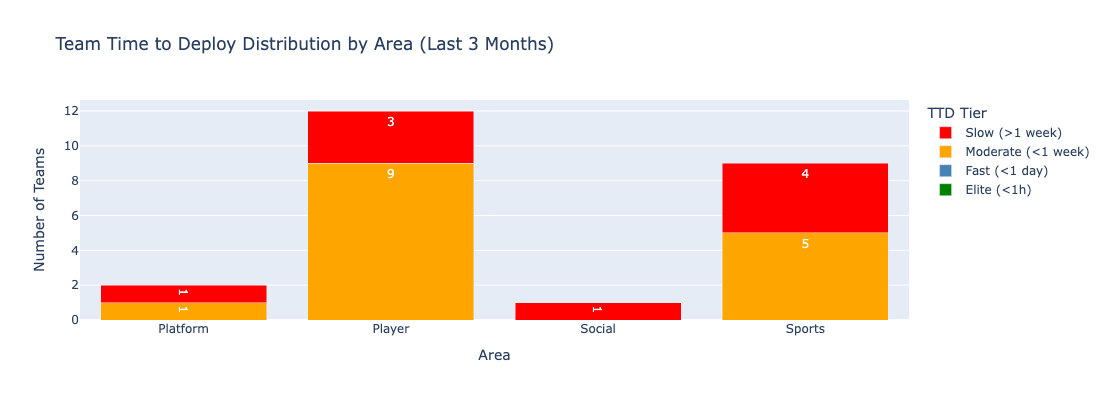


Teams by Area and TTD Tier:


,Area,Team,Median TTD (hours),Tier
0,Platform,App Frameworks,72.1,Moderate
1,Platform,Release Engineering,212.1,Slow
2,Player,Player Onboarding - Backend,27.7,Moderate
3,Player,Manage Platform - Pasta,28.1,Moderate
4,Player,Player Experience - Gamification,39.6,Moderate
5,Player,Player Account - PAMster,45.0,Moderate
6,Player,Player Identity - OctoPAM,69.1,Moderate
7,Player,Transact,75.5,Moderate
8,Player,Fraud Prevention,91.2,Moderate
9,Player,Gamification,113.4,Moderate


In [105]:
# Stacked bar: Team TTD distribution by area
tier_colors = {'Elite': 'green', 'Fast': 'steelblue', 'Moderate': 'orange', 'Slow': 'red'}
tier_order = ['Elite', 'Fast', 'Moderate', 'Slow']
tier_labels = {
    'Elite': 'Elite (<1h)',
    'Fast': 'Fast (<1 day)',
    'Moderate': 'Moderate (<1 week)',
    'Slow': 'Slow (>1 week)'
}

areas = area_ttd_counts.index.tolist()

fig = go.Figure()
for tier in tier_order:
    fig.add_trace(go.Bar(
        name=tier_labels[tier],
        x=areas,
        y=area_ttd_counts[tier],
        marker_color=tier_colors[tier],
        text=area_ttd_counts[tier].apply(lambda x: str(int(x)) if x > 0 else ''),
        textposition='inside',
        textfont=dict(color='white', size=12)
    ))

fig.update_layout(
    barmode='stack',
    title='Team Time to Deploy Distribution by Area (Last 3 Months)',
    xaxis_title='Area',
    yaxis_title='Number of Teams',
    legend_title='TTD Tier',
    height=400
)
fig.show()

# Show team table
print("\nTeams by Area and TTD Tier:")
print("=" * 70)
team_table = df_team_ttd[['area', 'team_name', 'median_ttd_hours', 'ttd_tier']].copy()
team_table = team_table.sort_values(['area', 'median_ttd_hours'], ascending=[True, True])
team_table.columns = ['Area', 'Team', 'Median TTD (hours)', 'Tier']
display(team_table.reset_index(drop=True))

## Summary

Key metrics at a glance for each area.

## Deep Dive: What Drives TTD?

Let's investigate what factors correlate with deployment speed. 

**Hypothesis**: Smaller, more frequent deploys should be faster. Large batched deploys might indicate manual processes or less mature CI/CD.

In [114]:
# Batch Size Analysis: Does bundling PRs slow down deploys?
df_batch = run_query(f"""
WITH deploy_stats AS (
    SELECT 
        ARRAY_SIZE(pull_request_ids) as prs_per_deploy,
        time_to_deploy_seconds
    FROM RAW_MISC.SWARMIA_DEPLOYMENTS 
    WHERE {ENV_FILTER}
        AND time_to_deploy_seconds IS NOT NULL
        AND pull_request_ids IS NOT NULL
        AND deployed_at >= DATEADD('month', -6, DATE_TRUNC('month', CURRENT_DATE))
        AND DATE_TRUNC('month', deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
),
bucketed AS (
    SELECT 
        CASE 
            WHEN prs_per_deploy = 1 THEN '1 PR'
            WHEN prs_per_deploy <= 3 THEN '2-3 PRs'
            WHEN prs_per_deploy <= 5 THEN '4-5 PRs'
            ELSE '6+ PRs'
        END as batch_size,
        CASE 
            WHEN prs_per_deploy = 1 THEN 1
            WHEN prs_per_deploy <= 3 THEN 2
            WHEN prs_per_deploy <= 5 THEN 3
            ELSE 4
        END as sort_order,
        time_to_deploy_seconds
    FROM deploy_stats
)
SELECT 
    batch_size,
    sort_order,
    COUNT(*) as deployments,
    ROUND(MEDIAN(time_to_deploy_seconds) / 3600.0, 1) as median_ttd_hours
FROM bucketed
GROUP BY 1, 2
ORDER BY sort_order
""")

df_batch['deployments'] = df_batch['deployments'].astype(int)
df_batch['median_ttd_hours'] = df_batch['median_ttd_hours'].astype(float)

print("Batch Size: PRs per Deployment (Last 6 Months)")
print("=" * 50)
for _, row in df_batch.iterrows():
    print(f"  {row['batch_size']:<10} {row['deployments']:>5} deploys  →  {row['median_ttd_hours']:.1f}h median TTD")

Batch Size: PRs per Deployment (Last 6 Months)
  1 PR        1082 deploys  →  24.1h median TTD
  2-3 PRs      752 deploys  →  23.5h median TTD
  4-5 PRs      291 deploys  →  20.7h median TTD
  6+ PRs       940 deploys  →  218.5h median TTD


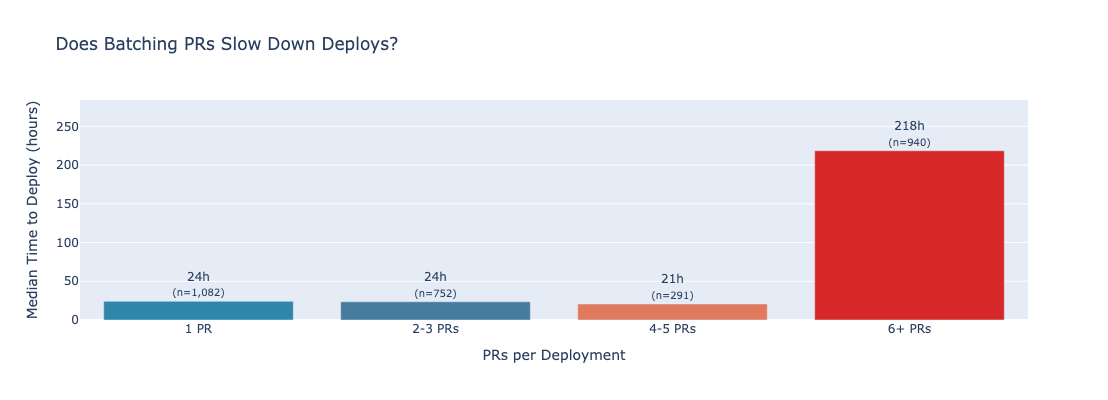


Key insight:
  35% of deployments contain just 1 PR
  Single-PR deploys: 24h median TTD
  Multi-PR deploys:  116h median TTD (4.8x slower)


In [115]:
# Visualize: Batch size vs TTD - single clear chart
fig = go.Figure()

# Color gradient: smaller batches = better (blue), larger = worse (orange/red)
colors = ['#2E86AB', '#457B9D', '#E07A5F', '#D62828']

fig.add_trace(go.Bar(
    x=df_batch['batch_size'],
    y=df_batch['median_ttd_hours'],
    marker_color=colors[:len(df_batch)],
    text=[f"{h:.0f}h<br><span style='font-size:10px'>(n={n:,})</span>" 
          for h, n in zip(df_batch['median_ttd_hours'], df_batch['deployments'])],
    textposition='outside',
    hovertemplate='%{x}<br>Median TTD: %{y:.1f}h<extra></extra>'
))

fig.update_layout(
    title='Does Batching PRs Slow Down Deploys?',
    xaxis_title='PRs per Deployment',
    yaxis_title='Median Time to Deploy (hours)',
    height=400,
    showlegend=False,
    yaxis=dict(range=[0, df_batch['median_ttd_hours'].max() * 1.3])
)
fig.show()

# Key insight
single_pr = df_batch[df_batch['batch_size'] == '1 PR']
multi_pr = df_batch[df_batch['batch_size'] != '1 PR']

if len(single_pr) > 0 and len(multi_pr) > 0:
    single_ttd = single_pr['median_ttd_hours'].iloc[0]
    single_count = single_pr['deployments'].iloc[0]
    total_deploys = df_batch['deployments'].sum()
    single_pct = single_count / total_deploys * 100
    
    # Weighted avg for multi-PR
    multi_ttd = (multi_pr['median_ttd_hours'] * multi_pr['deployments']).sum() / multi_pr['deployments'].sum()
    
    print(f"\nKey insight:")
    print(f"  {single_pct:.0f}% of deployments contain just 1 PR")
    print(f"  Single-PR deploys: {single_ttd:.0f}h median TTD")
    print(f"  Multi-PR deploys:  {multi_ttd:.0f}h median TTD ({multi_ttd/single_ttd:.1f}x slower)")

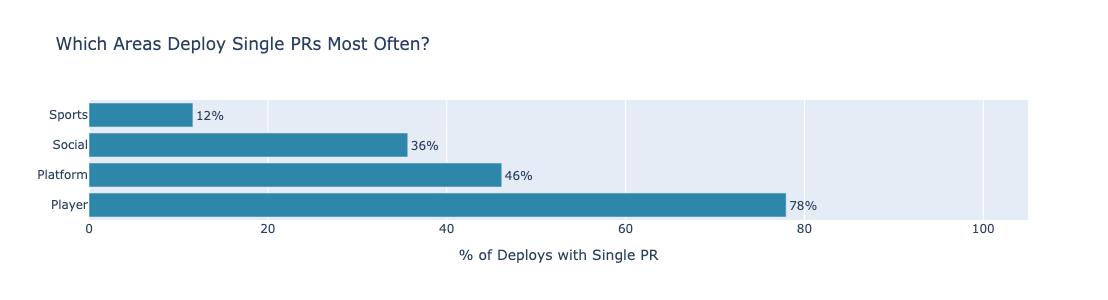


Batch size by area (Last 6 Months):
Area         Deploys    Avg PRs    % Single-PR
---------------------------------------------
Player       871        1.5        78%
Platform     182        5.8        46%
Social       303        1.5        36%
Sports       1816       13.4       12%


In [116]:
# Batch size by Area: Which areas batch more?
queries = []
for area, filter_clause in AREA_FILTERS.items():
    queries.append(f"""
        SELECT 
            '{area}' as area,
            COUNT(*) as deployments,
            ROUND(AVG(ARRAY_SIZE(pull_request_ids)), 1) as avg_prs_per_deploy,
            SUM(CASE WHEN ARRAY_SIZE(pull_request_ids) = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as pct_single_pr
        FROM RAW_MISC.SWARMIA_DEPLOYMENTS 
        WHERE {filter_clause}
            AND pull_request_ids IS NOT NULL
            AND deployed_at >= DATEADD('month', -6, DATE_TRUNC('month', CURRENT_DATE))
            AND DATE_TRUNC('month', deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
    """)

df_batch_area = run_query(" UNION ALL ".join(queries) + " ORDER BY pct_single_pr DESC")
for col in ['deployments', 'avg_prs_per_deploy', 'pct_single_pr']:
    df_batch_area[col] = df_batch_area[col].astype(float)

# Simple horizontal bar: % single-PR deploys by area
fig = go.Figure()

fig.add_trace(go.Bar(
    y=df_batch_area['area'],
    x=df_batch_area['pct_single_pr'],
    orientation='h',
    marker_color='#2E86AB',
    text=[f"{p:.0f}%" for p in df_batch_area['pct_single_pr']],
    textposition='outside',
    hovertemplate='%{y}<br>%{x:.0f}% single-PR deploys<extra></extra>'
))

fig.update_layout(
    title='Which Areas Deploy Single PRs Most Often?',
    xaxis_title='% of Deploys with Single PR',
    yaxis_title='',
    height=300,
    xaxis=dict(range=[0, 105]),
    showlegend=False
)
fig.show()

# Text summary
print(f"\nBatch size by area (Last 6 Months):")
print(f"{'Area':<12} {'Deploys':<10} {'Avg PRs':<10} {'% Single-PR'}")
print("-" * 45)
for _, row in df_batch_area.iterrows():
    print(f"{row['area']:<12} {int(row['deployments']):<10} {row['avg_prs_per_deploy']:<10.1f} {row['pct_single_pr']:.0f}%")

### Lines Changed per Deployment

Does the size of code changes affect deployment speed?

In [ ]:
# Lines Changed per Deployment: Do larger code changes take longer to deploy?
df_lines = run_query(f"""
WITH deploy_prs AS (
    SELECT 
        d.id as deployment_id,
        d.time_to_deploy_seconds,
        f.value::string as pr_id
    FROM RAW_MISC.SWARMIA_DEPLOYMENTS d,
        LATERAL FLATTEN(input => d.pull_request_ids) f
    WHERE {ENV_FILTER}
        AND d.time_to_deploy_seconds IS NOT NULL
        AND d.pull_request_ids IS NOT NULL
        AND d.deployed_at >= DATEADD('month', -6, DATE_TRUNC('month', CURRENT_DATE))
        AND DATE_TRUNC('month', d.deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
),
deploy_lines AS (
    SELECT 
        dp.deployment_id,
        dp.time_to_deploy_seconds,
        SUM(COALESCE(pr.additions, 0) + COALESCE(pr.deletions, 0)) as total_lines
    FROM deploy_prs dp
    LEFT JOIN RAW_MISC.SWARMIA_PULL_REQUESTS pr ON dp.pr_id = pr.id
    GROUP BY 1, 2
),
bucketed AS (
    SELECT 
        CASE 
            WHEN total_lines <= 100 THEN 'Small (≤100)'
            WHEN total_lines <= 500 THEN 'Medium (101-500)'
            WHEN total_lines <= 1000 THEN 'Large (501-1000)'
            ELSE 'XL (>1000)'
        END as size_bucket,
        CASE 
            WHEN total_lines <= 100 THEN 1
            WHEN total_lines <= 500 THEN 2
            WHEN total_lines <= 1000 THEN 3
            ELSE 4
        END as sort_order,
        time_to_deploy_seconds
    FROM deploy_lines
    WHERE total_lines IS NOT NULL
)
SELECT 
    size_bucket,
    sort_order,
    COUNT(*) as deployments,
    ROUND(MEDIAN(time_to_deploy_seconds) / 3600.0, 1) as median_ttd_hours
FROM bucketed
GROUP BY 1, 2
ORDER BY sort_order
""")

df_lines['deployments'] = df_lines['deployments'].astype(int)
df_lines['median_ttd_hours'] = df_lines['median_ttd_hours'].astype(float)

print("Deployment Size: Lines Changed (Last 6 Months)")
print("=" * 50)
for _, row in df_lines.iterrows():
    print(f"  {row['size_bucket']:<18} {row['deployments']:>5} deploys  →  {row['median_ttd_hours']:.1f}h median TTD")

In [ ]:
# Visualize: Deployment size vs TTD - single clear chart
fig = go.Figure()

# Color gradient: smaller = better (blue), larger = worse (orange/red)
colors = ['#2E86AB', '#457B9D', '#E07A5F', '#D62828']

fig.add_trace(go.Bar(
    x=df_lines['size_bucket'],
    y=df_lines['median_ttd_hours'],
    marker_color=colors[:len(df_lines)],
    text=[f"{h:.0f}h<br><span style='font-size:10px'>(n={n:,})</span>" 
          for h, n in zip(df_lines['median_ttd_hours'], df_lines['deployments'])],
    textposition='outside',
    hovertemplate='%{x}<br>Median TTD: %{y:.1f}h<extra></extra>'
))

fig.update_layout(
    title='Do Larger Code Changes Take Longer to Deploy?',
    xaxis_title='Lines Changed per Deployment',
    yaxis_title='Median Time to Deploy (hours)',
    height=400,
    showlegend=False,
    yaxis=dict(range=[0, df_lines['median_ttd_hours'].max() * 1.3])
)
fig.show()

# Key insight
small = df_lines[df_lines['size_bucket'].str.contains('Small')]
large = df_lines[df_lines['size_bucket'].str.contains('Large|XL')]

if len(small) > 0 and len(large) > 0:
    small_ttd = small['median_ttd_hours'].iloc[0]
    small_count = small['deployments'].iloc[0]
    total_deploys = df_lines['deployments'].sum()
    small_pct = small_count / total_deploys * 100
    
    # Weighted avg for large
    large_ttd = (large['median_ttd_hours'] * large['deployments']).sum() / large['deployments'].sum()
    
    print(f"\nKey insight:")
    print(f"  {small_pct:.0f}% of deployments are small (≤100 lines)")
    print(f"  Small deploys: {small_ttd:.0f}h median TTD")
    print(f"  Large deploys: {large_ttd:.0f}h median TTD ({large_ttd/small_ttd:.1f}x slower)")

### Deep Dive Summary

**What drives faster deployments?**

| Factor | Finding |
|--------|---------|
| **Batch Size** | Bundling multiple PRs correlates with slower deploys |
| **Deployment Size** | Larger code changes take longer to deploy |

**Recommendations:**
1. **Deploy smaller batches** - Single-PR deployments are faster
2. **Break up large changes** - Smaller code changes deploy more quickly

In [ ]:
# Summary view by Area (compute overview inline)
queries = []
for area, filter_clause in AREA_FILTERS.items():
    queries.append(f"""
        SELECT
            '{area}' as area,
            COUNT(*) * 1.0 / NULLIF(COUNT(DISTINCT DATE_TRUNC('month', deployed_at)), 0) as deploys_per_month,
            MEDIAN(time_to_deploy_seconds) / 3600.0 as median_ttd_hours
        FROM RAW_MISC.SWARMIA_DEPLOYMENTS
        WHERE {filter_clause}
            AND deployed_at >= DATEADD('month', -6, DATE_TRUNC('month', CURRENT_DATE))
            AND DATE_TRUNC('month', deployed_at) < DATE_TRUNC('month', CURRENT_DATE)
        GROUP BY 1
    """)

df_overview = run_query(" UNION ALL ".join(queries) + " ORDER BY area")

print("DORA Summary by Area (6-Month Baseline)")
print("=" * 60)
print("\n{:<12} {:>12} {:>15} {:>12}".format(
    'Area', 'Deploys/Mo', 'Median TTD', 'Performance'))
print("-" * 60)

for _, row in df_overview.iterrows():
    deploys = int(float(row['deploys_per_month']))
    ttd_hours = float(row['median_ttd_hours'])

    # Performance tier
    if ttd_hours < 1: tier = "Elite"
    elif ttd_hours < 24: tier = "Fast"
    elif ttd_hours < 168: tier = "Moderate"
    else: tier = "Slow"

    print("{:<12} {:>12} {:>13.1f}h {:>12}".format(
        row['area'], deploys, ttd_hours, tier))

---

## Appendix: Area Production Filter Definitions

*Reference material for the production filters used in this analysis.*

| Area | Filter Logic | Notes |
|------|-------------|-------|
| **Social** | `deployment_environment LIKE 'backend.social/production%'` | Backend microservices only, excludes web.social frontend |
| **Player** | `LENGTH(deployment_app_name) = 6` + `environment = prod/production` | 6-letter naming convention for backend services |
| **Sports** | Environment list (monorepo) | content-prod/*, incubator-prod/*, trading-prod/* clusters |
| **Platform** | Environment list (monorepo) | engprod-prod/*, meta-prod/*, ops-prod/* clusters |

Full environment lists are defined in the setup cell at the top of this notebook.